# Fig 5: Methylation Stats

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import glob
import gzip

In [2]:
# Color scheme for tissues (defines the plotting order)
color_dict = {
    'Brain_LeftAnteriorCortex': '#678AB8',  
    'Brain_LeftPosteriorCortex': '#8FA9CC', 
    'Kidney_Left-Cortex-1': '#E68A87',            
    'Kidney_Right-Cortex-1': '#D67874',           
    'Liver_LeftLobe': '#8DA585',                  
    'Liver_RightLobe': '#A1B597',                 
    'Liver_MedianLobe': '#AEB470'                  
}

# Function to format tissue names for display
def format_tissue_name(name):
    """Convert tissue names to readable format"""
    # Replace underscores with spaces
    name = name.replace('_', ' ')
    # Add spaces before capital letters in camelCase
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    # Handle special cases like "-Cortex-1"
    name = name.replace('-', ' ')
    # Remove trailing " 1" from kidney cortex names
    name = re.sub(r'\s+1$', '', name)
    return name

# Plot Number of reads by tissue (methylation library)

In [3]:
def extract_data_from_single_log(log_file_path):
    """Extract read count and alignment rate from a single log file"""
    with open(log_file_path, 'r') as file:
        log_text = file.read()
    
    # Regular expressions for extracting data
    total_reads_regex = r"There are (\d+) total input reads"
    alignment_rate_regex = r"There are \d+ uniquely mapping reads, ([\d\.]+) percent remaining"
    
    # Extract values
    total_reads_match = re.search(total_reads_regex, log_text)
    alignment_rate_match = re.search(alignment_rate_regex, log_text)
    
    if total_reads_match and alignment_rate_match:
        return {
            'Number of Reads': int(total_reads_match.group(1)),
            'Alignment Rate': float(alignment_rate_match.group(1))
        }
    return None

# Directory containing log files
log_dir = '/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/methylation/methylpy/log'

# Find all log files
log_files = glob.glob(os.path.join(log_dir, '*_methylpy.log'))

# Extract data from all log files
data_list = []
for log_file in log_files:
    # Extract sample_id from filename (remove _methylpy.log)
    sample_id = os.path.basename(log_file).replace('_methylpy.log', '')
    
    # Extract data from log
    data = extract_data_from_single_log(log_file)
    
    if data:
        data['sample_id'] = sample_id
        data_list.append(data)

# Create DataFrame
df_reads = pd.DataFrame(data_list)

print(f"Extracted {len(df_reads)} samples from log files")
print(f"\nFirst few samples:")
df_reads.head()

Extracted 216 samples from log files

First few samples:


,Number of Reads,Alignment Rate,sample_id
0,532859,35.591779,Liver_LeftLobe_Plate1-12F
1,575261,37.529574,Liver_MedianLobe_Plate1-1E
2,1211506,44.616122,Brain_LeftAnteriorCortex_Plate1-6F
3,1717564,38.969028,Brain_LeftPosteriorCortex_Plate1-2E
4,2325228,38.175482,Liver_LeftLobe_Plate1-7F


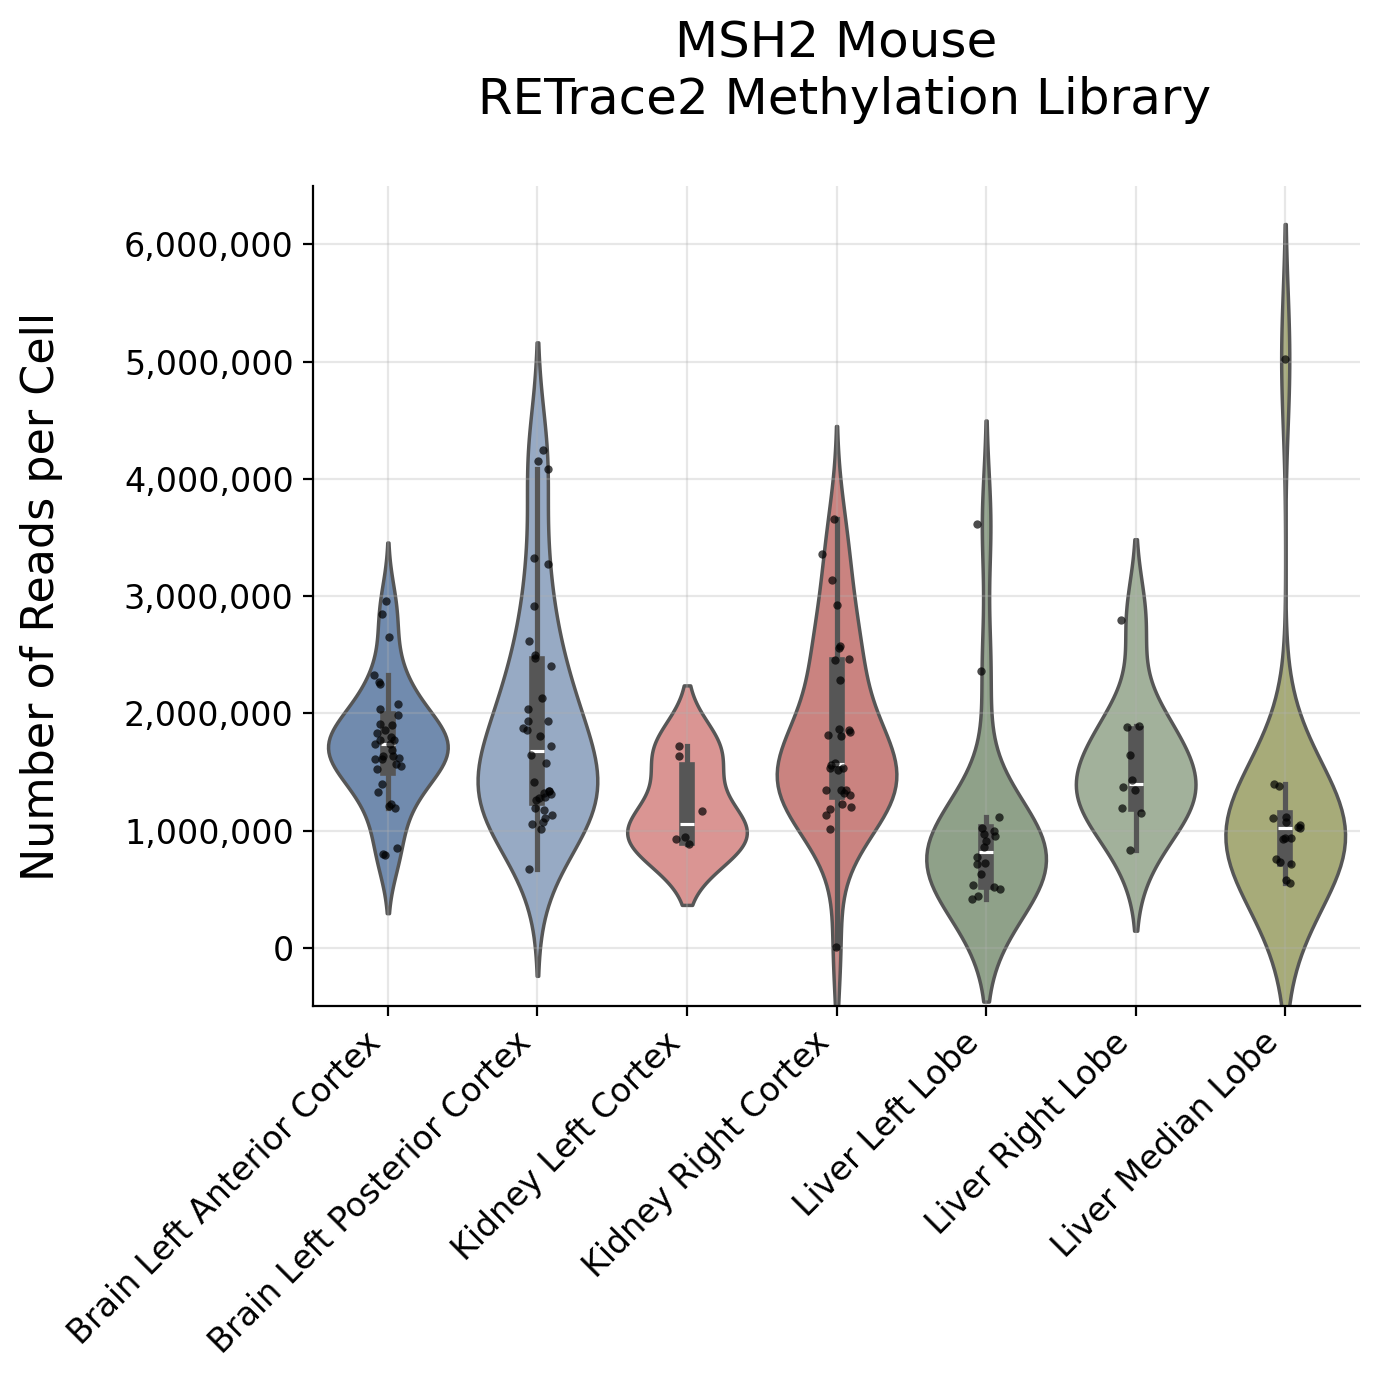


Summary Statistics:
                           count          mean           std       min  \
tissue_detail                                                            
Brain_LeftAnteriorCortex    35.0  1.741962e+06  5.052213e+05  792028.0   
Brain_LeftPosteriorCortex   36.0  1.930551e+06  9.361612e+05  675626.0   
Kidney_Left-Cortex-1         6.0  1.213596e+06  3.726163e+05  886929.0   
Kidney_Right-Cortex-1       30.0  1.824275e+06  7.864095e+05    7158.0   
Liver_LeftLobe              18.0  1.004486e+06  7.837609e+05  420653.0   
Liver_RightLobe             10.0  1.553842e+06  5.458334e+05  835157.0   
Liver_MedianLobe            17.0  1.196733e+06  1.014538e+06  550926.0   

                                  25%        50%         75%        max  
tissue_detail                                                            
Brain_LeftAnteriorCortex   1535211.00  1739271.0  1947983.00  2961354.0  
Brain_LeftPosteriorCortex  1274663.25  1683289.0  2418463.00  4250578.0  
Kidney_Left-Cort

/tmp/ipykernel_87101/983719364.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_reads_pass.groupby('tissue_detail')['Number of Reads'].describe())


In [4]:
# Read sample stats to get pass/fail information
df_stats = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')

# Merge read counts with sample stats
df_merged = df_reads.merge(df_stats[['sample_id', 'pass']], on='sample_id', how='left')

# Filter for passing samples only
df_reads_pass = df_merged[df_merged['pass'] == True].copy()

# Extract detailed tissue names (first two parts before "_Plate")
df_reads_pass['tissue_detail'] = df_reads_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict, filter to only those present in data
unique_tissues = [t for t in color_dict.keys() if t in df_reads_pass['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

# Convert tissue_detail to categorical with specified order for proper plotting
df_reads_pass['tissue_detail'] = pd.Categorical(df_reads_pass['tissue_detail'], 
                                                  categories=unique_tissues, 
                                                  ordered=True)

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='Number of Reads', data=df_reads_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='Number of Reads', data=df_reads_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 Mouse\n RETrace2 Methylation Library\n", fontsize=18)
ax.set_ylabel('Number of Reads per Cell\n', fontsize=16)

ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-500000, 6500000)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Format y-axis to show numbers in scientific notation or with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('reads_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df_reads_pass.groupby('tissue_detail')['Number of Reads'].describe())
print(f"\nTotal passing samples: {len(df_reads_pass)}")
print(f"\nSamples per tissue:\n{df_reads_pass['tissue_detail'].value_counts()}")


# Plot Alignment Rate by Tissue

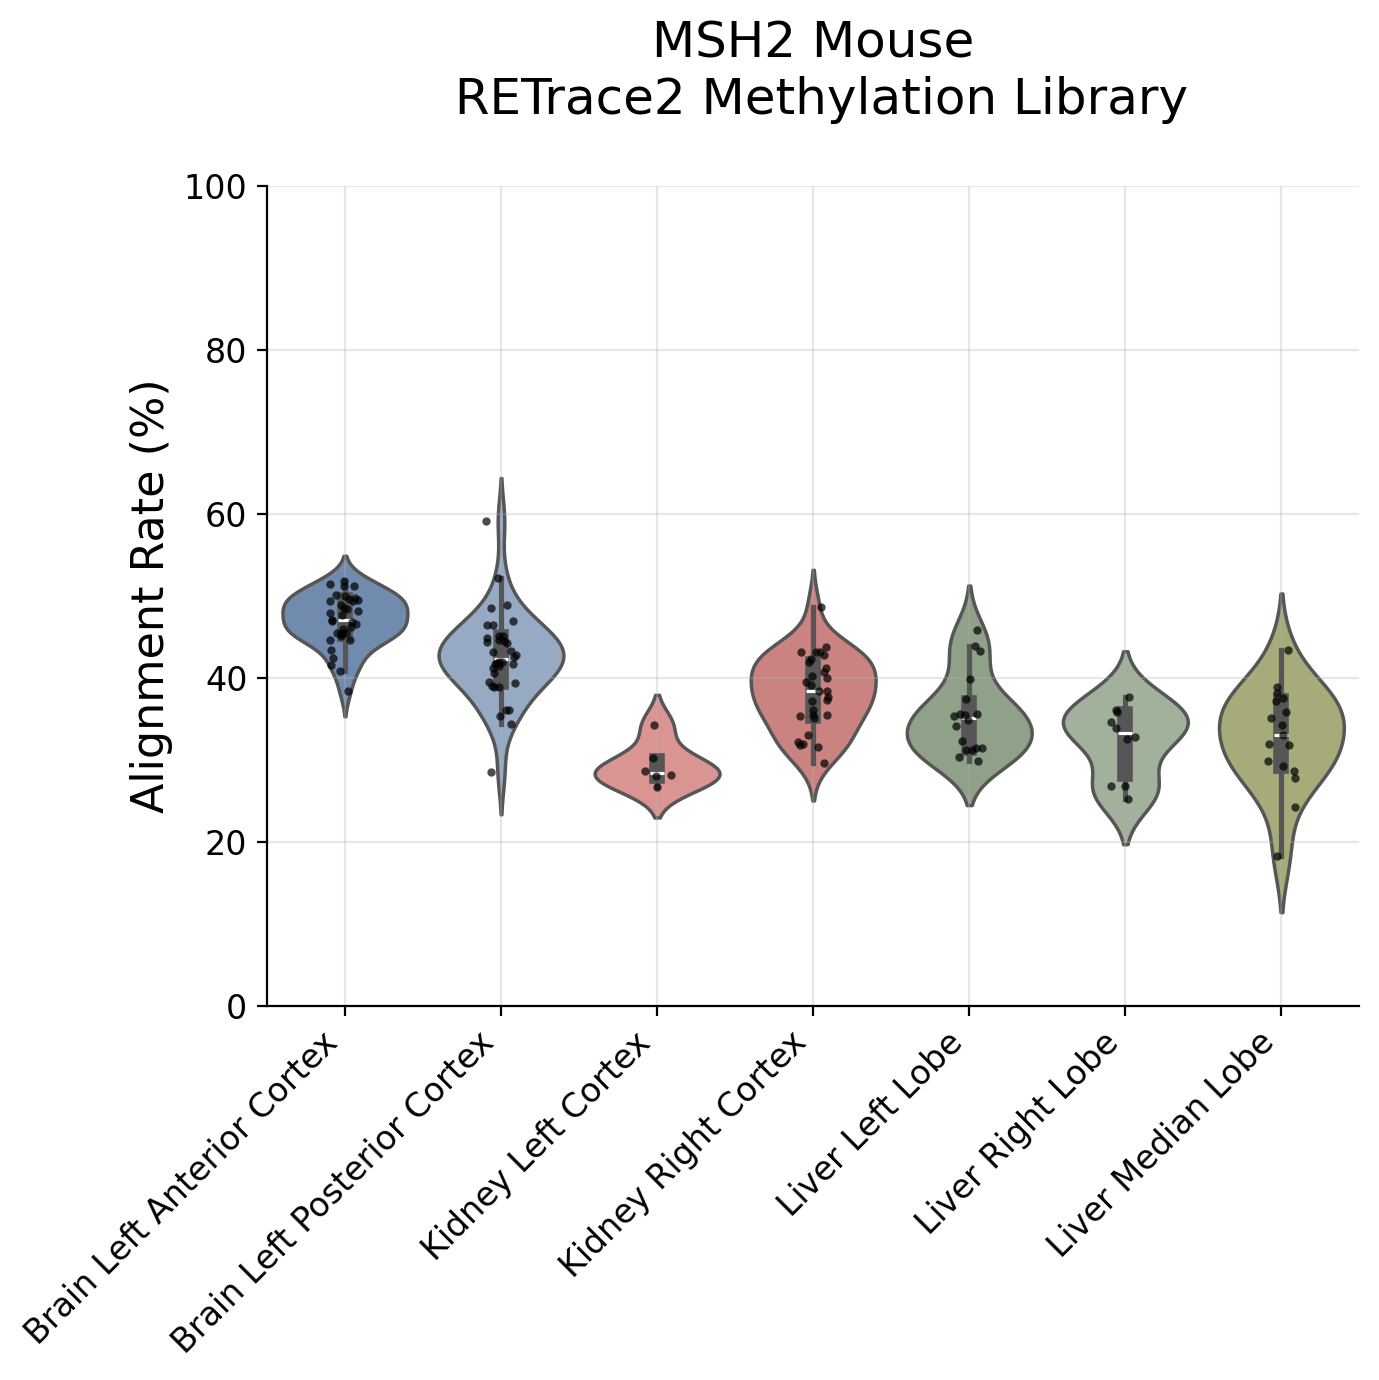


Alignment Rate Summary Statistics:
                           count       mean       std        min        25%  \
tissue_detail                                                                 
Brain_LeftAnteriorCortex    35.0  47.036881  3.159493  38.470274  45.423800   
Brain_LeftPosteriorCortex   36.0  42.597885  5.327288  28.623511  39.508625   
Kidney_Left-Cortex-1         6.0  29.388142  2.651671  26.739415  28.135795   
Kidney_Right-Cortex-1       30.0  38.255197  4.516274  29.675674  35.404740   
Liver_LeftLobe              18.0  35.544352  4.841152  29.968921  31.486965   
Liver_RightLobe             10.0  32.288050  4.388295  25.310664  28.329606   
Liver_MedianLobe            17.0  32.710758  6.039778  18.350392  29.357720   

                                 50%        75%        max  
tissue_detail                                               
Brain_LeftAnteriorCortex   47.129680  49.485910  51.816875  
Brain_LeftPosteriorCortex  42.330832  44.983254  59.191394  
Kidney_L

/tmp/ipykernel_87101/775347399.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_reads_pass_align.groupby('tissue_detail')['Alignment Rate'].describe())


In [5]:
# Use the same merged dataframe (df_reads_pass already has alignment rate)
df_reads_pass_align = df_reads_pass.copy()

# Get tissues in the order specified by color_dict
unique_tissues = [t for t in color_dict.keys() if t in df_reads_pass_align['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='Alignment Rate', data=df_reads_pass_align, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='Alignment Rate', data=df_reads_pass_align, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 Mouse\n RETrace2 Methylation Library\n", fontsize=18)
ax.set_ylabel('Alignment Rate (%)', fontsize=16)

ax.tick_params(axis='both', labelsize=12)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('alignment_rate_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nAlignment Rate Summary Statistics:")
print(df_reads_pass_align.groupby('tissue_detail')['Alignment Rate'].describe())
print(f"\nTotal passing samples: {len(df_reads_pass_align)}")
print(f"\nSamples per tissue:\n{df_reads_pass_align['tissue_detail'].value_counts()}")

# Plot CpG count by tissue

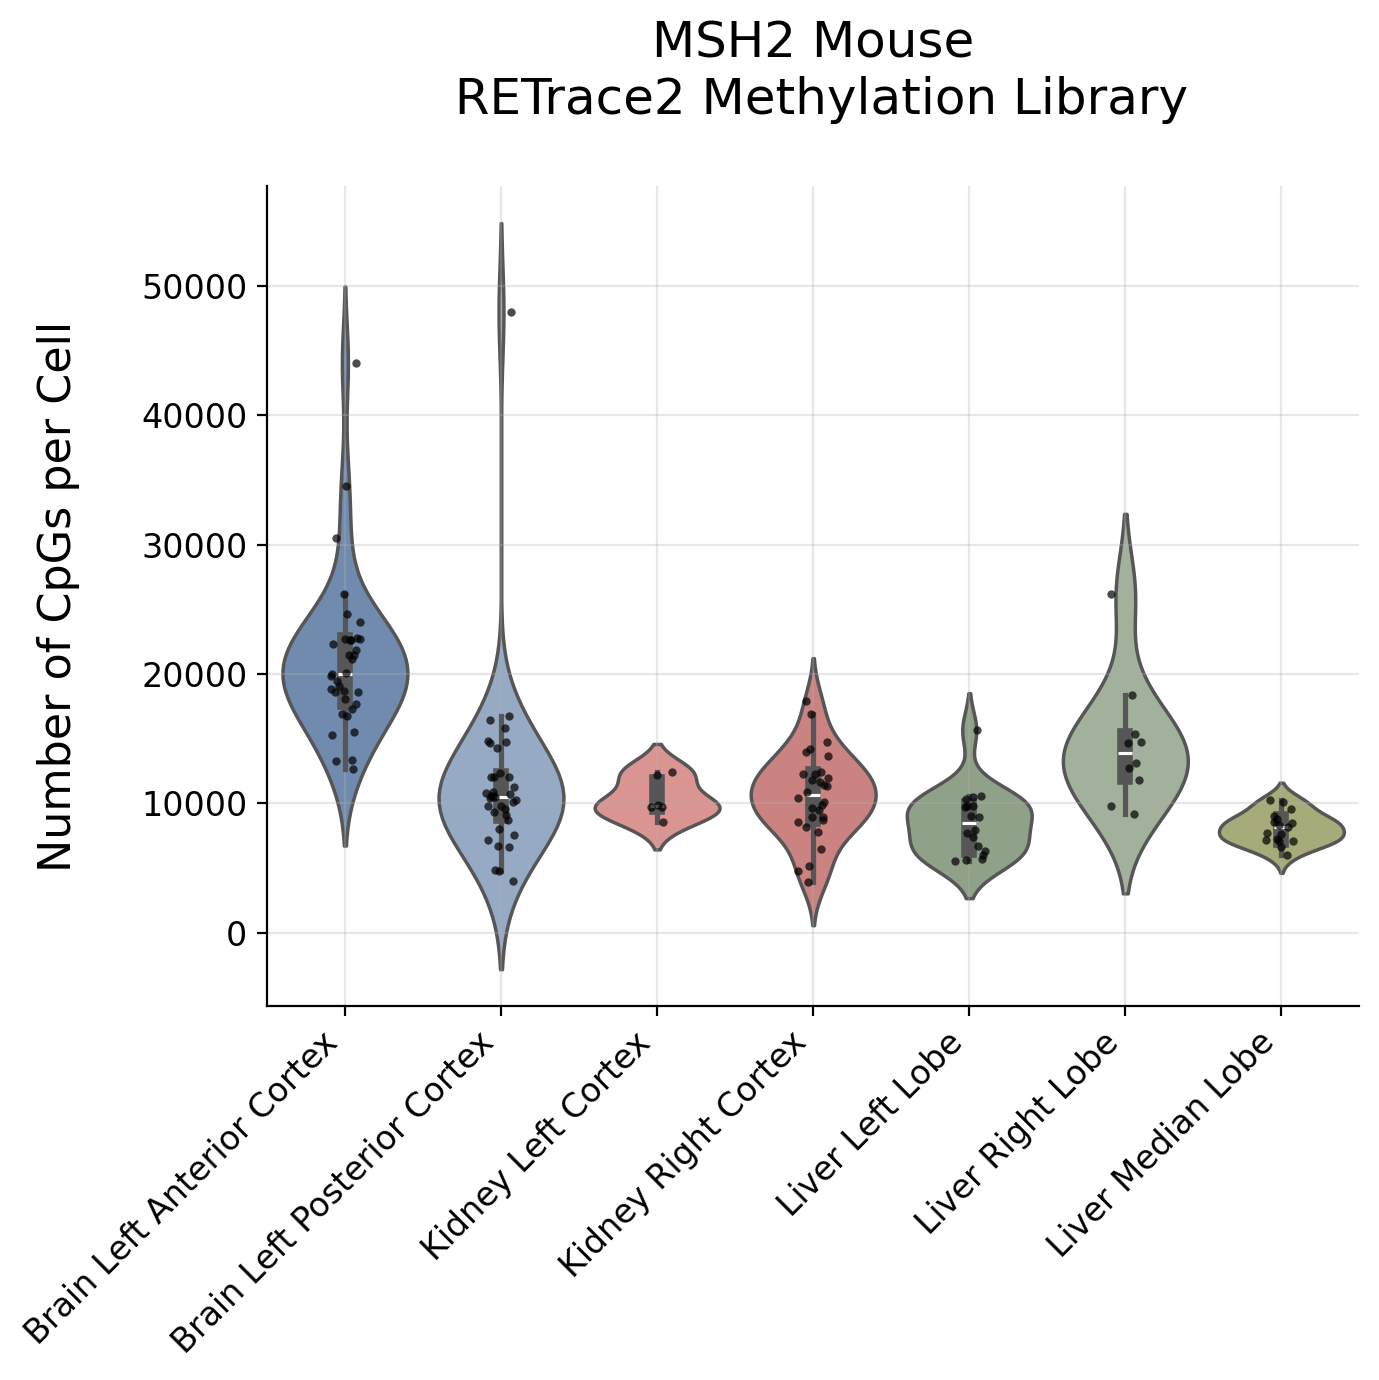


Summary Statistics:
                           count          mean          std      min  \
tissue_detail                                                          
Brain_LeftAnteriorCortex    35.0  21018.000000  5995.673337  12633.0   
Brain_LeftPosteriorCortex   36.0  11553.916667  7006.995759   4038.0   
Kidney_Left-Cortex-1         6.0  10442.833333  1540.332356   8600.0   
Kidney_Right-Cortex-1       30.0  10615.000000  3290.601255   3918.0   
Liver_LeftLobe              18.0   8522.888889  2542.231324   5531.0   
Liver_RightLobe             10.0  14608.000000  4888.867353   9220.0   
Liver_MedianLobe            17.0   8111.058824  1204.942347   6001.0   

                                25%      50%       75%      max  
tissue_detail                                                    
Brain_LeftAnteriorCortex   17868.00  19975.0  22665.50  44052.0  
Brain_LeftPosteriorCortex   9014.75  10513.5  12118.50  47992.0  
Kidney_Left-Cortex-1        9723.25   9837.5  11651.25  12441.0  


/tmp/ipykernel_87101/1970971821.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_pass.groupby('tissue_detail')['cpg_count'].describe())


In [6]:
# Read the data
df = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')

# Filter for samples that pass
df_pass = df[df['pass'] == True].copy()

# Extract detailed tissue names (first two parts before "_Plate")
df_pass['tissue_detail'] = df_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict, filter to only those present in data
unique_tissues = [t for t in color_dict.keys() if t in df_pass['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

# Convert tissue_detail to categorical with specified order for proper plotting
df_pass['tissue_detail'] = pd.Categorical(df_pass['tissue_detail'], 
                                           categories=unique_tissues, 
                                           ordered=True)

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='cpg_count', data=df_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='cpg_count', data=df_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 Mouse\n RETrace2 Methylation Library\n", fontsize=18)
ax.set_ylabel('Number of CpGs per Cell\n', fontsize=16)

ax.tick_params(axis='both', labelsize=12)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('cpg_count_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df_pass.groupby('tissue_detail')['cpg_count'].describe())
print(f"\nTotal passing samples: {len(df_pass)}")
print(f"\nSamples per tissue:\n{df_pass['tissue_detail'].value_counts()}")

# Plot CG and CH Methylation Rates by Tissue

In [7]:
def calculate_methylation_rates(allc_file):
    """
    Calculate CG and CH methylation rates from an allc file.
    
    Returns a dictionary with CG and CH methylation rates.
    """
    # Initialize counters
    cg_mc_total = 0  # Total methylated CG counts
    cg_cov_total = 0  # Total CG coverage
    ch_mc_total = 0  # Total methylated CH counts
    ch_cov_total = 0  # Total CH coverage
    
    # Check if file is gzipped
    is_gzipped = allc_file.endswith('.gz')
    
    if is_gzipped:
        f = gzip.open(allc_file, 'rt')
    else:
        f = open(allc_file, 'r')
    
    try:
        for line in f:
            if line.startswith('#'):  # Skip header lines
                continue
            
            fields = line.strip().split('\t')
            if len(fields) >= 6:
                # ALLC format: chr, pos, strand, context, mc, cov, methylated
                context = fields[3]
                mc = int(fields[4])  # Methylated count
                cov = int(fields[5])  # Coverage
                
                # CG context
                if context.startswith('CG'):
                    cg_mc_total += mc
                    cg_cov_total += cov
                # CH context (CA, CC, CT - anything starting with C but not CG)
                elif context.startswith('C') and not context.startswith('CG'):
                    ch_mc_total += mc
                    ch_cov_total += cov
    finally:
        f.close()
    
    # Calculate methylation rates
    cg_rate = (cg_mc_total / cg_cov_total * 100) if cg_cov_total > 0 else 0
    ch_rate = (ch_mc_total / ch_cov_total * 100) if ch_cov_total > 0 else 0
    
    return {
        'CG_methylation_rate': cg_rate,
        'CH_methylation_rate': ch_rate,
        'CG_sites': cg_cov_total,
        'CH_sites': ch_cov_total
    }

# Directory containing allc files
allc_dir = '/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/methylation/methylpy/allc'

# Find all allc files
allc_files = glob.glob(os.path.join(allc_dir, 'allc_*.tsv.gz'))

print(f"Found {len(allc_files)} allc files")
print("Processing allc files to calculate methylation rates...")

# Process all allc files
methylation_data = []
for i, allc_file in enumerate(allc_files):
    # Extract sample_id from filename (remove allc_ prefix and .tsv.gz suffix)
    sample_id = os.path.basename(allc_file).replace('allc_', '').replace('.tsv.gz', '')
    
    # Calculate methylation rates
    rates = calculate_methylation_rates(allc_file)
    rates['sample_id'] = sample_id
    methylation_data.append(rates)
    
    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(allc_files)} files...")

# Create DataFrame
df_meth = pd.DataFrame(methylation_data)

print(f"\nCompleted processing {len(df_meth)} samples")
print("\nFirst few samples:")
df_meth.head()


Found 216 allc files
Processing allc files to calculate methylation rates...
Processed 50/216 files...
Processed 100/216 files...
Processed 150/216 files...
Processed 200/216 files...

Completed processing 216 samples

First few samples:


,CG_methylation_rate,CH_methylation_rate,CG_sites,CH_sites,sample_id
0,29.931141,1.558894,1983035,17044585,Liver_LeftLobe_Plate1-9E
1,45.029498,18.036522,3802312,35738093,Liver_MedianLobe_Plate1-12D
2,33.458295,1.597423,1716800,14236433,Liver_LeftLobe_Plate1-9D
3,36.148149,3.360362,1579251,14408863,Kidney_Left-Cortex-1_Plate1-9E
4,35.385974,4.532015,1985394,21482541,Brain_LeftPosteriorCortex_Plate1-1C


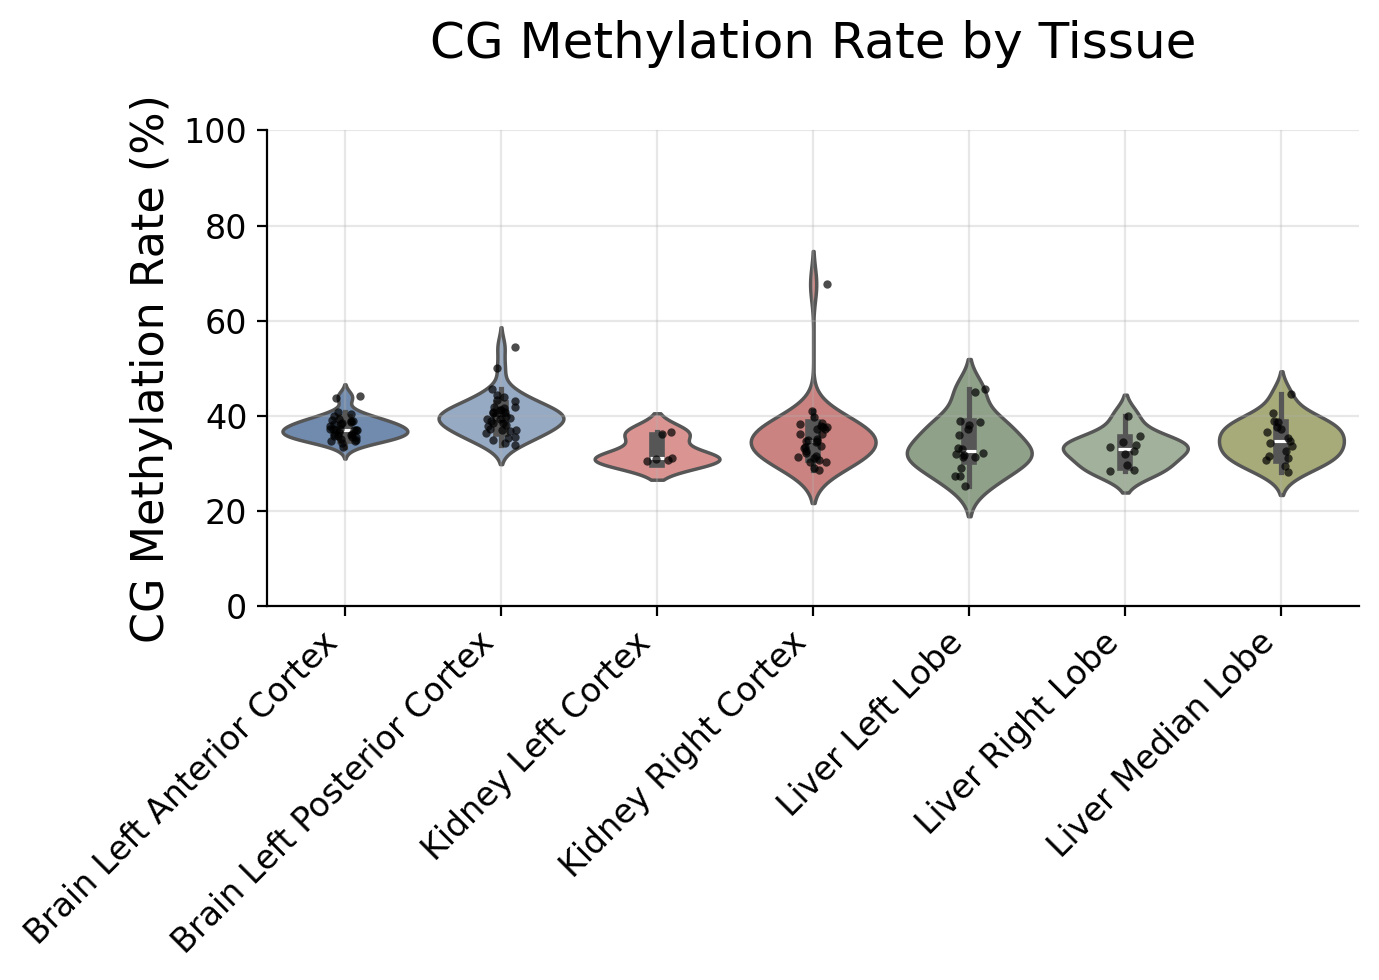


CG Methylation Rate Summary Statistics:
                           count       mean       std        min        25%  \
tissue_detail                                                                 
Brain_LeftAnteriorCortex    35.0  37.497613  2.413852  33.420483  35.857176   
Brain_LeftPosteriorCortex   36.0  40.115875  4.185836  33.969835  37.191626   
Kidney_Left-Cortex-1         6.0  32.715862  2.841472  30.587438  30.833602   
Kidney_Right-Cortex-1       30.0  35.618798  6.875212  28.683875  31.805451   
Liver_LeftLobe              18.0  34.103977  5.652157  25.279315  31.441487   
Liver_RightLobe             10.0  32.918475  3.551049  28.404954  30.216148   
Liver_MedianLobe            17.0  35.099335  4.286035  28.271324  31.668184   

                                 50%        75%        max  
tissue_detail                                               
Brain_LeftAnteriorCortex   37.137532  38.762732  44.285590  
Brain_LeftPosteriorCortex  39.593603  41.712496  54.555845  
Kid

/tmp/ipykernel_87101/3960307691.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_meth_pass.groupby('tissue_detail')['CG_methylation_rate'].describe())


In [8]:
# Merge methylation data with sample stats
df_stats = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')
df_meth_merged = df_meth.merge(df_stats[['sample_id', 'pass']], on='sample_id', how='left')

# Filter for passing samples only
df_meth_pass = df_meth_merged[df_meth_merged['pass'] == True].copy()

# Extract detailed tissue names
df_meth_pass['tissue_detail'] = df_meth_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict
unique_tissues = [t for t in color_dict.keys() if t in df_meth_pass['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

# Convert tissue_detail to categorical with specified order
df_meth_pass['tissue_detail'] = pd.Categorical(df_meth_pass['tissue_detail'], 
                                                 categories=unique_tissues, 
                                                 ordered=True)

# Plot CG Methylation Rate
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)

sns.violinplot(x='tissue_detail', y='CG_methylation_rate', data=df_meth_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='CG_methylation_rate', data=df_meth_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("CG Methylation Rate by Tissue\n", fontsize=18)
ax.set_ylabel('CG Methylation Rate (%)', fontsize=16)

ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(0, 100)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('CG_methylation_rate_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nCG Methylation Rate Summary Statistics:")
print(df_meth_pass.groupby('tissue_detail')['CG_methylation_rate'].describe())
print(f"\nTotal passing samples: {len(df_meth_pass)}")
print(f"\nSamples per tissue:\n{df_meth_pass['tissue_detail'].value_counts()}")


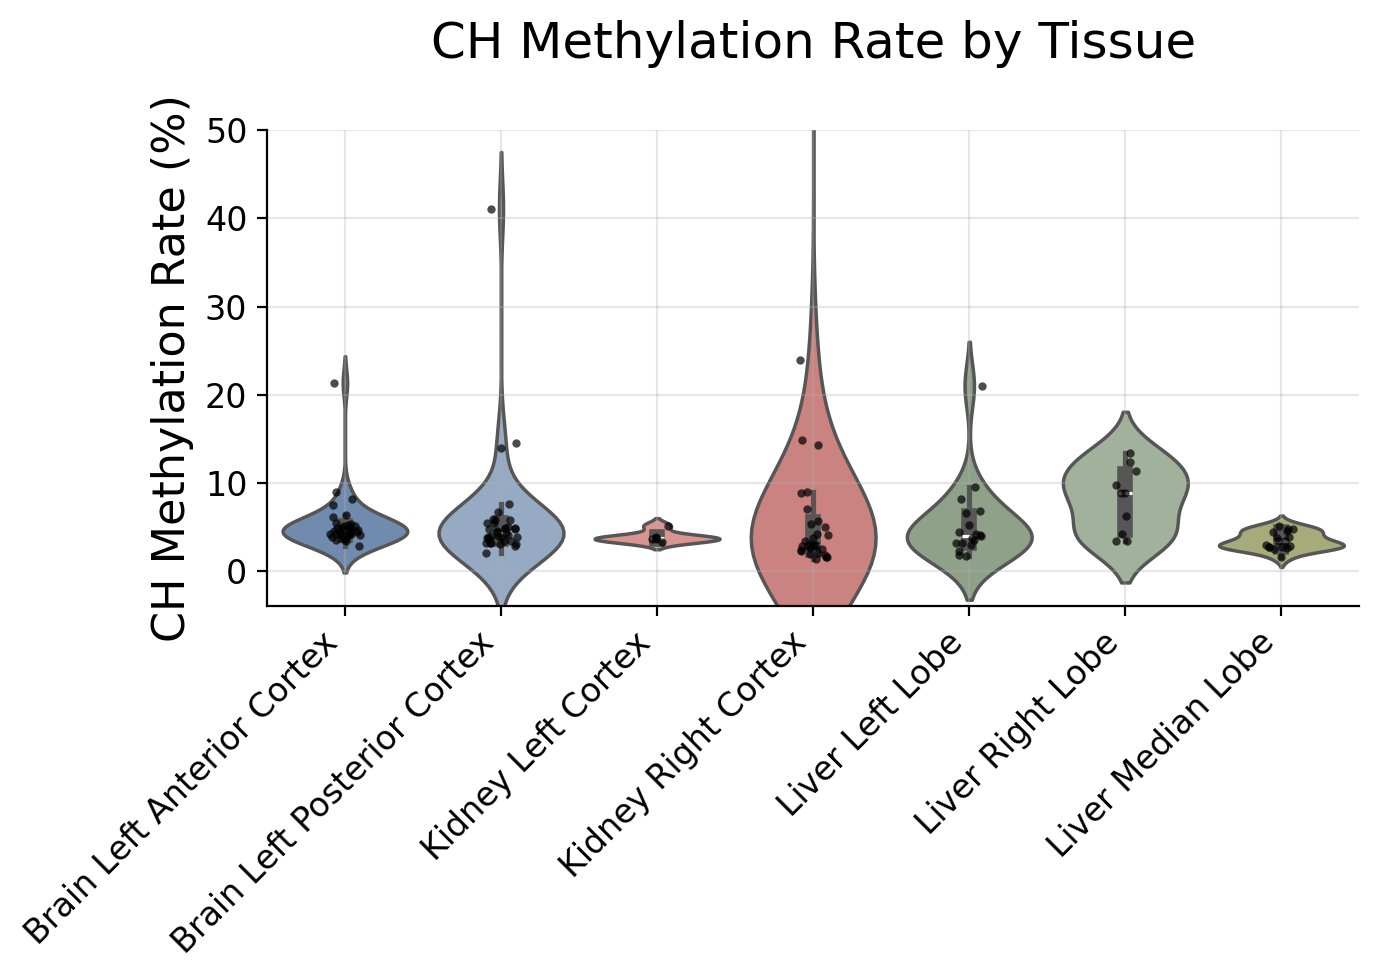


CH Methylation Rate Summary Statistics:
                           count      mean        std       min       25%  \
tissue_detail                                                               
Brain_LeftAnteriorCortex    35.0  5.327410   3.075111  2.864006  4.138380   
Brain_LeftPosteriorCortex   36.0  5.925899   6.557879  2.016594  3.634812   
Kidney_Left-Cortex-1         6.0  3.910970   0.627208  3.360362  3.641815   
Kidney_Right-Cortex-1       30.0  7.421911  13.723789  1.371911  2.400607   
Liver_LeftLobe              18.0  5.378641   4.446912  1.750314  3.237175   
Liver_RightLobe             10.0  8.193895   3.701792  3.393482  4.698588   
Liver_MedianLobe            17.0  3.469775   1.003696  1.615808  2.720394   

                                50%        75%        max  
tissue_detail                                              
Brain_LeftAnteriorCortex   4.637318   5.178453  21.355822  
Brain_LeftPosteriorCortex  4.366843   5.458090  41.126802  
Kidney_Left-Cortex-1     

/tmp/ipykernel_87101/1742665554.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_meth_pass.groupby('tissue_detail')['CH_methylation_rate'].describe())


In [9]:
# Plot CH Methylation Rate
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)

sns.violinplot(x='tissue_detail', y='CH_methylation_rate', data=df_meth_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='CH_methylation_rate', data=df_meth_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("CH Methylation Rate by Tissue\n", fontsize=18)
ax.set_ylabel('CH Methylation Rate (%)', fontsize=16)

ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-4, 50)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('CH_methylation_rate_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nCH Methylation Rate Summary Statistics:")
print(df_meth_pass.groupby('tissue_detail')['CH_methylation_rate'].describe())
print(f"\nTotal passing samples: {len(df_meth_pass)}")
print(f"\nSamples per tissue:\n{df_meth_pass['tissue_detail'].value_counts()}")


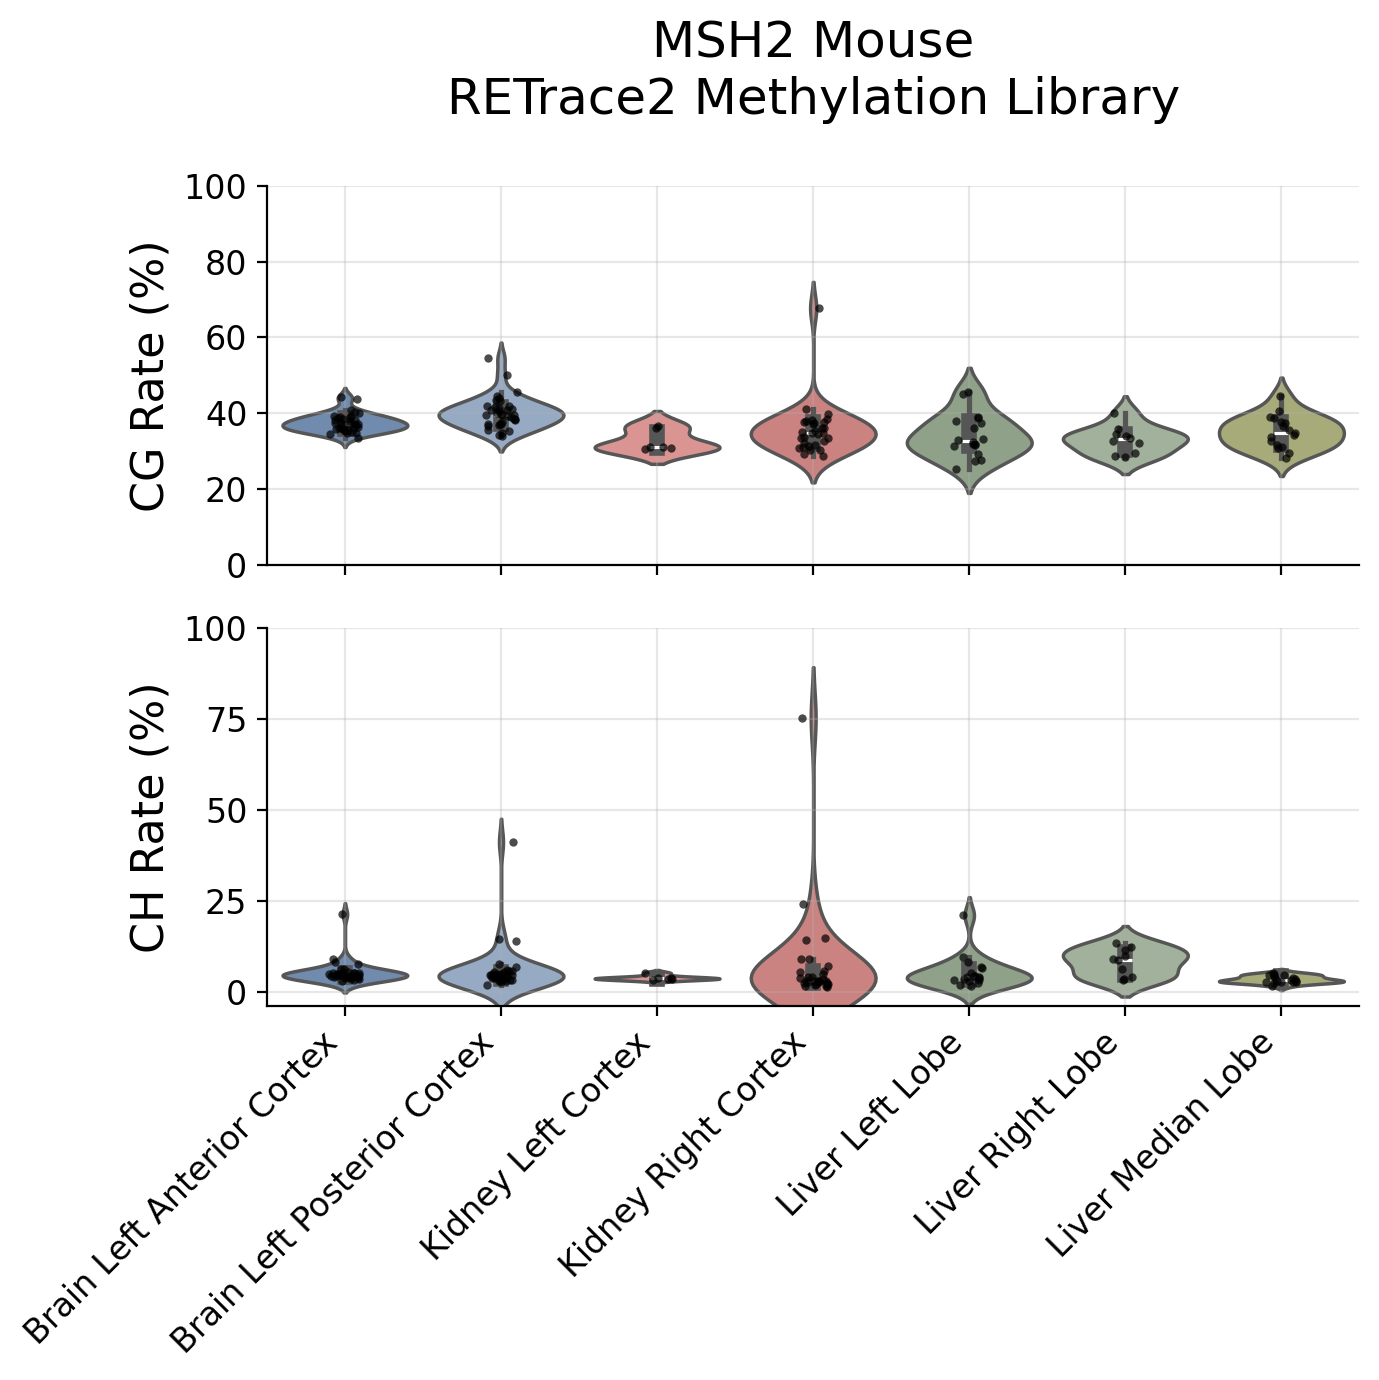

In [10]:
# Create combined plot: CG (top) and CH (bottom)
fig, axes = plt.subplots(2, 1, figsize=(7, 7), dpi=200)

# Top panel: CG Methylation Rate
ax1 = axes[0]
sns.violinplot(x='tissue_detail', y='CG_methylation_rate', data=df_meth_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax1)
sns.stripplot(x='tissue_detail', y='CG_methylation_rate', data=df_meth_pass, color='black', ax=ax1, size=3, alpha=0.7)

ax1.set_xlabel("")
ax1.set_title("MSH2 Mouse\nRETrace2 Methylation Library\n", fontsize=18)
ax1.set_ylabel('CG Rate (%)', fontsize=16)
ax1.tick_params(axis='both', labelsize=12)
ax1.set_ylim(0, 100)
ax1.set_xticks(range(len(unique_tissues)))
ax1.set_xticklabels([])  # Remove x-tick labels for top panel
ax1.grid(True, alpha=0.3)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Bottom panel: CH Methylation Rate
ax2 = axes[1]
sns.violinplot(x='tissue_detail', y='CH_methylation_rate', data=df_meth_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax2)
sns.stripplot(x='tissue_detail', y='CH_methylation_rate', data=df_meth_pass, color='black', ax=ax2, size=3, alpha=0.7)

ax2.set_xlabel("")
ax2.set_ylabel('CH Rate (%)', fontsize=16)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_ylim(-4, 100)
ax2.set_xticks(range(len(unique_tissues)))
ax2.set_xticklabels(tissue_labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('CG_CH_methylation_rate_by_tissue_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Bisulfte Conversion Rate

# Plot Bisulfite Conversion Rate by Tissue

**Note:** Bisulfite conversion rates are calculated from lambda phage DNA (unmethylated control) spiked into libraries.

```bash
~/software/RETrace2/scripts/lambda_bisulfite.sh \
    -i "/path/to/fastq/Methyl*fastq.gz" \
    -o test_lambda_output_20250422 \
    -g "/home/tcheng/Projects/GenomeDB/lambda" \
    -b "/home/tcheng/software/Bismark-0.24.2/bismark" \
    -t 20
```

**Parameters:**
- `-i`: Input fastq files (can use wildcards or space-separated list)
- `-o`: Output directory
- `-g`: Path to lambda genome directory (Bismark index)
- `-b`: Path to Bismark executable
- `-t`: Number of threads

**Interpretation:**
- Good conversion: ≥95%
- Acceptable: 90-95%
- Poor: <90% (may need to re-do library prep)


In [11]:
def parse_bisulfite_summary(summary_file):
    """
    Parse the lambda bisulfite conversion summary file.
    
    Returns a DataFrame with sample_id, mapping_efficiency, and bisulfite_conversion_rate.
    """
    data = []
    
    with open(summary_file, 'r') as f:
        current_sample = None
        for line in f:
            line = line.strip()
            
            # Parse sample name
            if line.startswith('Summary for'):
                # Extract sample name from "Summary for Methyl_MSH2_SC_..._:"
                sample_name = line.replace('Summary for ', '').replace(':', '').strip()
                # Clean up the sample name to extract just the tissue-plate part
                # Example: Methyl_MSH2_SC_Brain_LeftAnteriorCortex_20250422_Plate1-4B_
                # We want: Brain_LeftAnteriorCortex_Plate1-4B
                parts = sample_name.split('_')
                # Find the tissue part (after SC) and plate part
                try:
                    # Remove Methyl, MSH2, SC prefix and date (8-digit number), trailing underscore
                    tissue_parts = []
                    for i, p in enumerate(parts):
                        if i < 3:  # Skip Methyl, MSH2, SC
                            continue
                        if p.isdigit() and len(p) == 8:  # Skip date (8-digit number like 20250422)
                            continue
                        if p != '':  # Skip empty strings
                            tissue_parts.append(p)
                    
                    current_sample = '_'.join(tissue_parts).rstrip('_')
                except:
                    current_sample = sample_name
            
            # Parse bisulfite conversion rate
            elif 'Bisulfite conversion rate:' in line and current_sample:
                # Extract percentage: "Bisulfite conversion rate: 97.9% (..."
                rate = float(line.split(':')[1].split('%')[0].strip())
                data.append({
                    'sample_id': current_sample,
                    'bisulfite_conversion_rate': rate
                })
                current_sample = None
    
    return pd.DataFrame(data)

# Parse bisulfite conversion summary
bisulfite_summary_file = '/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/Bisulfite_ConversionRate/lambda_output_from_samplesheet/summary.txt'
df_bisulfite = parse_bisulfite_summary(bisulfite_summary_file)

print(f"Parsed {len(df_bisulfite)} samples from bisulfite summary")
print("\nFirst few samples:")
df_bisulfite.head(10)


Parsed 216 samples from bisulfite summary

First few samples:


,sample_id,bisulfite_conversion_rate
0,Brain_LeftAnteriorCortex_Plate1-1B,96.3
1,Brain_LeftAnteriorCortex_Plate1-1C,97.7
2,Brain_LeftAnteriorCortex_Plate1-1D,96.7
3,Brain_LeftAnteriorCortex_Plate1-1E,97.6
4,Brain_LeftAnteriorCortex_Plate1-1F,97.5
5,Brain_LeftAnteriorCortex_Plate1-1G,98.1
6,Brain_LeftAnteriorCortex_Plate1-2B,97.6
7,Brain_LeftAnteriorCortex_Plate1-2C,98.5
8,Brain_LeftAnteriorCortex_Plate1-2D,97.6
9,Brain_LeftAnteriorCortex_Plate1-2E,97.7


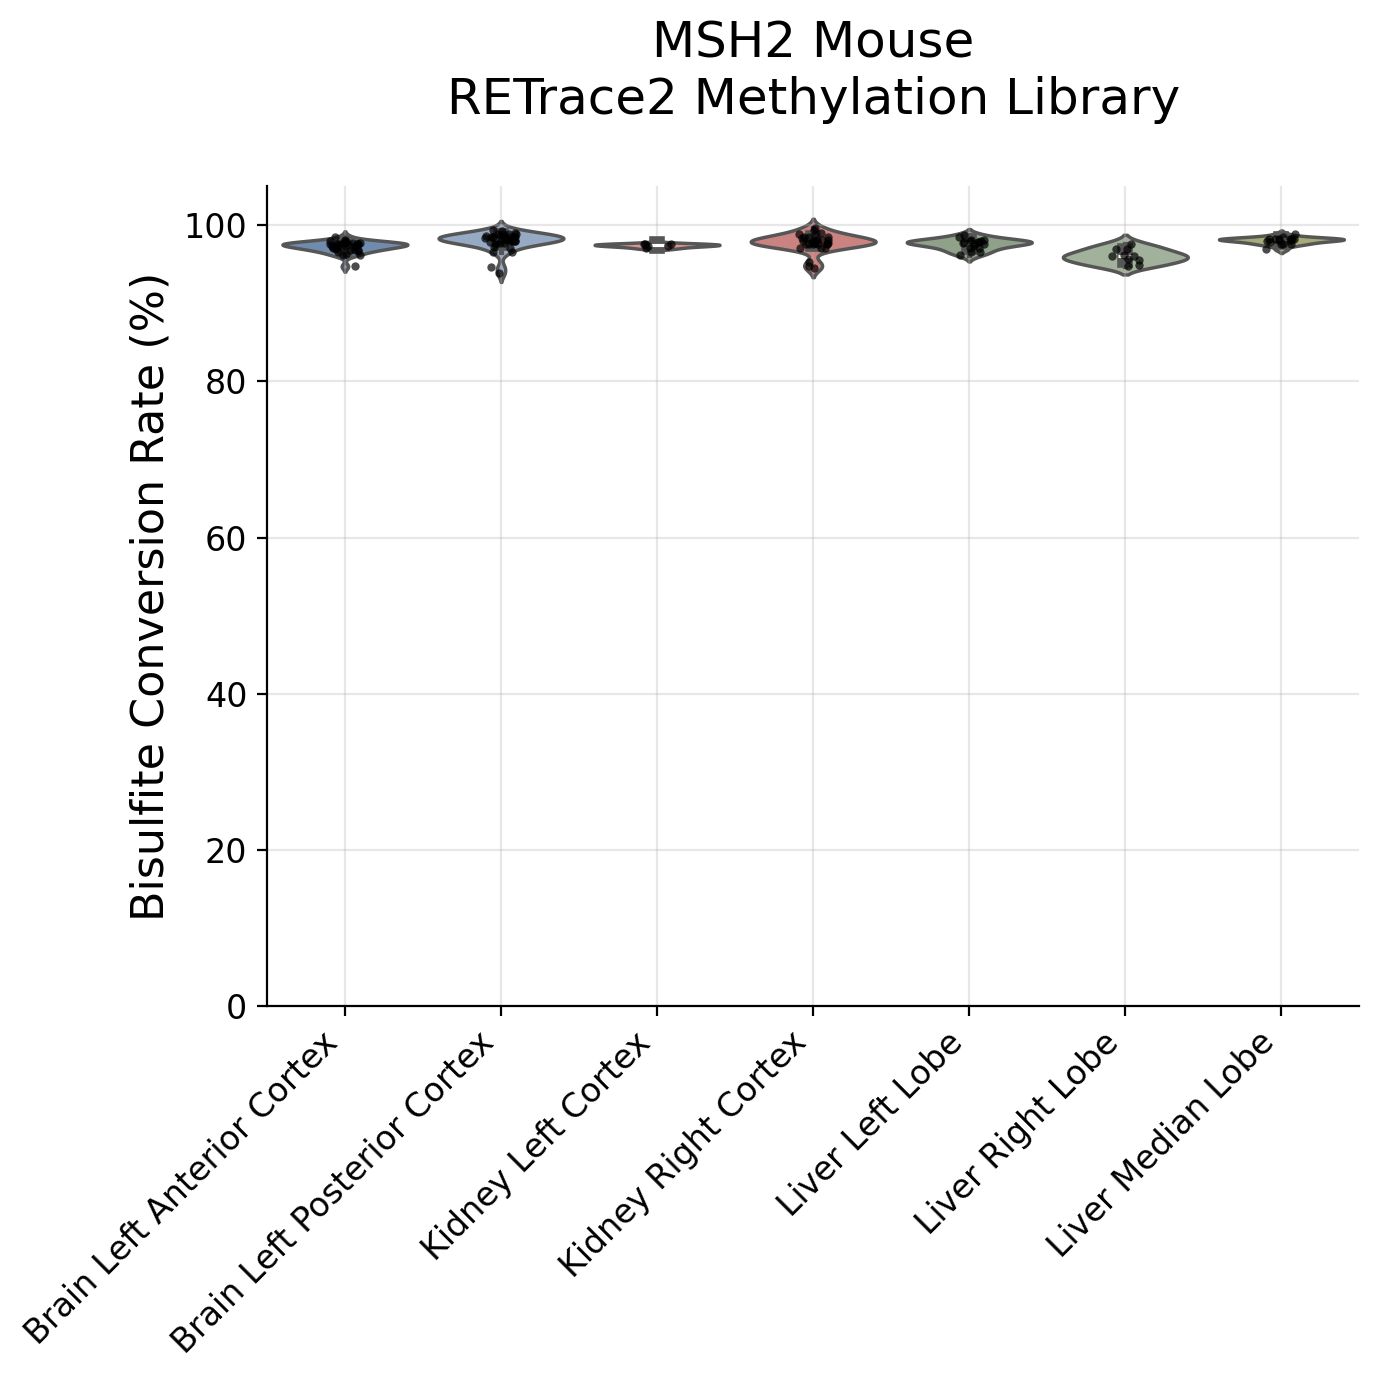


Bisulfite Conversion Rate Summary Statistics:
                           count       mean       std   min     25%    50%  \
tissue_detail                                                                
Brain_LeftAnteriorCortex    35.0  97.222857  0.696244  94.7  96.850  97.30   
Brain_LeftPosteriorCortex   36.0  97.947222  1.129725  93.8  97.700  98.15   
Kidney_Left-Cortex-1         6.0  97.366667  0.216025  97.0  97.300  97.40   
Kidney_Right-Cortex-1       30.0  97.706667  1.171775  94.5  97.525  97.75   
Liver_LeftLobe              18.0  97.555556  0.684468  96.1  97.150  97.75   
Liver_RightLobe             10.0  96.040000  0.898394  94.8  95.525  96.00   
Liver_MedianLobe            17.0  97.994118  0.433691  96.9  97.800  98.20   

                              75%   max  
tissue_detail                            
Brain_LeftAnteriorCortex   97.600  98.5  
Brain_LeftPosteriorCortex  98.525  99.4  
Kidney_Left-Cortex-1       97.500  97.6  
Kidney_Right-Cortex-1      98.375  99.6 

/tmp/ipykernel_87101/2633255246.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_bisulfite_pass.groupby('tissue_detail')['bisulfite_conversion_rate'].describe())


In [12]:
# Merge bisulfite data with sample stats
df_stats = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')
df_bisulfite_merged = df_bisulfite.merge(df_stats[['sample_id', 'pass']], on='sample_id', how='left')

# Filter for passing samples only
df_bisulfite_pass = df_bisulfite_merged[df_bisulfite_merged['pass'] == True].copy()

# Extract detailed tissue names
df_bisulfite_pass['tissue_detail'] = df_bisulfite_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict
unique_tissues = [t for t in color_dict.keys() if t in df_bisulfite_pass['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

# Convert tissue_detail to categorical with specified order
df_bisulfite_pass['tissue_detail'] = pd.Categorical(df_bisulfite_pass['tissue_detail'], 
                                                      categories=unique_tissues, 
                                                      ordered=True)

# Plot Bisulfite Conversion Rate
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='bisulfite_conversion_rate', data=df_bisulfite_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='bisulfite_conversion_rate', data=df_bisulfite_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 Mouse\nRETrace2 Methylation Library\n", fontsize=18)
ax.set_ylabel('Bisulfite Conversion Rate (%)', fontsize=16)

ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(0, 105)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('bisulfite_conversion_rate_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nBisulfite Conversion Rate Summary Statistics:")
print(df_bisulfite_pass.groupby('tissue_detail')['bisulfite_conversion_rate'].describe())
print(f"\nTotal passing samples: {len(df_bisulfite_pass)}")
print(f"\nSamples per tissue:\n{df_bisulfite_pass['tissue_detail'].value_counts()}")


# Overall Summary Statistics (All Passing Samples)


In [13]:
# Create comprehensive summary table for all passing samples
print("="*80)
print("OVERALL SUMMARY STATISTICS - ALL PASSING SAMPLES")
print("="*80)
print(f"\nTotal Passing Samples: {len(df_reads_pass)}")
print("\n" + "-"*80)

# Create summary dataframe
summary_data = {
    'Metric': [
        'Number of Reads',
        'Alignment Rate (%)',
        'CpG Count',
        'CG Methylation Rate (%)',
        'CH Methylation Rate (%)',
        'Bisulfite Conversion Rate (%)'
    ],
    'Mean': [
        df_reads_pass['Number of Reads'].mean(),
        df_reads_pass['Alignment Rate'].mean(),
        df_pass['cpg_count'].mean(),
        df_meth_pass['CG_methylation_rate'].mean(),
        df_meth_pass['CH_methylation_rate'].mean(),
        df_bisulfite_pass['bisulfite_conversion_rate'].mean()
    ],
    'Median': [
        df_reads_pass['Number of Reads'].median(),
        df_reads_pass['Alignment Rate'].median(),
        df_pass['cpg_count'].median(),
        df_meth_pass['CG_methylation_rate'].median(),
        df_meth_pass['CH_methylation_rate'].median(),
        df_bisulfite_pass['bisulfite_conversion_rate'].median()
    ],
    'Std Dev': [
        df_reads_pass['Number of Reads'].std(),
        df_reads_pass['Alignment Rate'].std(),
        df_pass['cpg_count'].std(),
        df_meth_pass['CG_methylation_rate'].std(),
        df_meth_pass['CH_methylation_rate'].std(),
        df_bisulfite_pass['bisulfite_conversion_rate'].std()
    ],
    'Min': [
        df_reads_pass['Number of Reads'].min(),
        df_reads_pass['Alignment Rate'].min(),
        df_pass['cpg_count'].min(),
        df_meth_pass['CG_methylation_rate'].min(),
        df_meth_pass['CH_methylation_rate'].min(),
        df_bisulfite_pass['bisulfite_conversion_rate'].min()
    ],
    'Max': [
        df_reads_pass['Number of Reads'].max(),
        df_reads_pass['Alignment Rate'].max(),
        df_pass['cpg_count'].max(),
        df_meth_pass['CG_methylation_rate'].max(),
        df_meth_pass['CH_methylation_rate'].max(),
        df_bisulfite_pass['bisulfite_conversion_rate'].max()
    ]
}

summary_df = pd.DataFrame(summary_data)

# Format the display
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(summary_df.to_string(index=False))
pd.reset_option('display.float_format')

print("\n" + "="*80)


OVERALL SUMMARY STATISTICS - ALL PASSING SAMPLES

Total Passing Samples: 152

--------------------------------------------------------------------------------
                       Metric         Mean       Median    Std Dev      Min          Max
              Number of Reads 1,621,328.44 1,423,393.00 828,778.96 7,158.00 5,023,143.00
           Alignment Rate (%)        39.62        39.97       7.14    18.35        59.19
                    CpG Count    12,960.91    10,770.00   6,780.75 3,918.00    47,992.00
      CG Methylation Rate (%)        36.59        36.58       5.18    25.28        67.68
      CH Methylation Rate (%)         5.81         4.18       7.29     1.37        75.25
Bisulfite Conversion Rate (%)        97.54        97.70       1.02    93.80        99.60



## Supplementary Table: Per-Cell Methylation Statistics

Comprehensive table of all methylation quality control metrics for ALL cells (both passing and failing QC), formatted to be combined with the MS stats.

In [18]:
# Create comprehensive per-cell methylation statistics table for ALL cells (pass and fail)
# Start with all samples (not just passing)
# df_reads contains all samples with read counts and alignment rates
# df_merged already has the 'pass' column from earlier merges

# Merge ALL methylation data together (using left joins to keep all cells)
df_meth_all = df_merged.merge(
    df_meth[['sample_id', 'CG_methylation_rate', 'CH_methylation_rate']], 
    on='sample_id', 
    how='left'
).merge(
    df_bisulfite[['sample_id', 'bisulfite_conversion_rate']], 
    on='sample_id', 
    how='left'
).merge(
    df_stats[['sample_id', 'cpg_count']], 
    on='sample_id', 
    how='left'
)

# Extract detailed tissue names (for all samples)
df_meth_all['tissue_detail'] = df_meth_all['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Create formatted table for export
methylation_table = pd.DataFrame({
    'sample_id': df_meth_all['sample_id'],
    'Tissue': df_meth_all['tissue_detail'].apply(format_tissue_name),
    'Pass_QC': df_meth_all['pass'],
    'Methylation_Number_of_Reads': df_meth_all['Number of Reads'],
    'Methylation_Alignment_Rate_Percent': df_meth_all['Alignment Rate'],
    'CpG_Count_1X': df_meth_all['cpg_count'],
    'CG_Methylation_Rate_Percent': df_meth_all['CG_methylation_rate'],
    'CH_Methylation_Rate_Percent': df_meth_all['CH_methylation_rate'],
    'Bisulfite_Conversion_Rate_Percent': df_meth_all['bisulfite_conversion_rate']
})

# Sort by sample_id for easy matching with MS stats
methylation_table = methylation_table.sort_values('sample_id').reset_index(drop=True)

print(f"Per-cell methylation statistics table created:")
print(f"  - Total cells: {len(methylation_table)}")
print(f"  - Passed QC: {methylation_table['Pass_QC'].sum()}")
print(f"  - Failed QC: {(~methylation_table['Pass_QC']).sum()}")
print(f"  - Columns: {len(methylation_table.columns)}")
methylation_table.head()


Per-cell methylation statistics table created:
  - Total cells: 216
  - Passed QC: 152
  - Failed QC: 64
  - Columns: 9


,sample_id,Tissue,Pass_QC,Methylation_Number_of_Reads,Methylation_Alignment_Rate_Percent,CpG_Count_1X,CG_Methylation_Rate_Percent,CH_Methylation_Rate_Percent,Bisulfite_Conversion_Rate_Percent
0,Brain_LeftAnteriorCortex_Plate1-1B,Brain Left Anterior Cortex,True,792028,49.717813,13338,37.355104,4.871749,96.3
1,Brain_LeftAnteriorCortex_Plate1-1C,Brain Left Anterior Cortex,True,2252066,51.272254,22630,39.151704,4.299219,97.7
2,Brain_LeftAnteriorCortex_Plate1-1D,Brain Left Anterior Cortex,True,2035237,47.901694,22791,37.796464,6.173999,96.7
3,Brain_LeftAnteriorCortex_Plate1-1E,Brain Left Anterior Cortex,True,1769813,49.458389,22728,38.913794,5.252988,97.6
4,Brain_LeftAnteriorCortex_Plate1-1F,Brain Left Anterior Cortex,True,1906167,49.696065,21150,35.880855,4.258358,97.5


In [19]:
# Save to CSV file
output_file = 'Supplementary_Table_MSH2_Per_Cell_Methylation_Statistics.csv'
methylation_table.to_csv(output_file, index=False)
print(f"Saved: {output_file}")


Saved: Supplementary_Table_MSH2_Per_Cell_Methylation_Statistics.csv
